# Project 3 Milestone 3 — Orbital Diagnostics / Angular Momentum Preparation

This notebook prepares orbital diagnostics for the Project 3 candidate sample.

The Project 3 M2 input table contains Galactocentric velocity components but does not contain valid parallax or distance information for the selected candidates. Since angular momentum requires both position and velocity, this notebook does **not** force an invalid angular-momentum calculation.

Instead, this milestone is implemented as a readiness-aware orbital diagnostics step:

1. preserve all Project 3 candidate rows;
2. compute available Galactocentric velocity diagnostics;
3. create angular-momentum diagnostic columns with missing values when position input is unavailable;
4. add explicit readiness flags for future full orbital analysis;
5. generate diagnostic figures showing the available velocity-space information and the orbital-readiness status.

Input:

- `data/processed/project3_orbit_input_candidates.csv`

Outputs:

- `data/processed/project3_orbital_diagnostics_candidates.csv`
- `figures/project3_orbital_diagnostics_velocity_summary.png`
- `figures/project3_orbital_diagnostics_feh_velocity.png`
- `figures/project3_orbital_diagnostics_readiness_summary.png`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 140)

ROOT = Path("..")
INPUT = ROOT / "data" / "processed" / "project3_orbit_input_candidates.csv"
OUTPUT = ROOT / "data" / "processed" / "project3_orbital_diagnostics_candidates.csv"

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT.exists(), f"Missing input file: {INPUT}"
df = pd.read_csv(INPUT)

print(df.shape)
df.head()


(27, 18)


,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,bp_rp,absolute_g_mag,feh,tangential_velocity_kms,galcen_vx,galcen_vy,galcen_vz,galcen_vtot,has_astrometric_6d_input,has_galcen_velocity_input,orbit_input_ready
0,3077457042404665088,NaN,NaN,NaN,NaN,NaN,NaN,1.252923,1.686704,-0.599,111.015798,NaN,NaN,NaN,NaN,False,False,False
1,3089847099636770560,NaN,NaN,NaN,NaN,NaN,NaN,0.618819,3.726077,-2.213,413.706467,NaN,NaN,NaN,NaN,False,False,False
2,3089944573918027648,NaN,NaN,NaN,NaN,NaN,NaN,0.984529,1.568062,-1.472,426.686109,NaN,NaN,NaN,NaN,False,False,False
3,3089534353001157632,NaN,NaN,NaN,NaN,NaN,NaN,1.041462,0.871324,-1.539,376.116952,NaN,NaN,NaN,NaN,False,False,False
4,3084095863550902528,NaN,NaN,NaN,NaN,NaN,NaN,0.728496,2.774414,-1.723,357.805943,NaN,NaN,NaN,NaN,False,False,False


In [2]:
print("Columns:")
for col in df.columns:
    print(col)


Columns:
source_id
ra
dec
parallax
pmra
pmdec
radial_velocity
bp_rp
absolute_g_mag
feh
tangential_velocity_kms
galcen_vx
galcen_vy
galcen_vz
galcen_vtot
has_astrometric_6d_input
has_galcen_velocity_input
orbit_input_ready


In [3]:
required_cols = [
    "source_id",
    "ra",
    "dec",
    "parallax",
    "pmra",
    "pmdec",
    "radial_velocity",
    "bp_rp",
    "absolute_g_mag",
    "feh",
    "tangential_velocity_kms",
    "galcen_vx",
    "galcen_vy",
    "galcen_vz",
    "galcen_vtot",
    "has_astrometric_6d_input",
    "has_galcen_velocity_input",
    "orbit_input_ready",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

work = df.copy()

numeric_cols = [
    "ra",
    "dec",
    "parallax",
    "pmra",
    "pmdec",
    "radial_velocity",
    "bp_rp",
    "absolute_g_mag",
    "feh",
    "tangential_velocity_kms",
    "galcen_vx",
    "galcen_vy",
    "galcen_vz",
    "galcen_vtot",
]

for col in numeric_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

print("Input rows:", len(work))
print("Valid parallax rows:", int((work["parallax"] > 0).sum()))
print("Rows with Galactocentric velocity input:", int(work["has_galcen_velocity_input"].sum()))
print("Rows marked orbit_input_ready:", int(work["orbit_input_ready"].sum()))


Input rows: 27
Valid parallax rows: 0
Rows with Galactocentric velocity input: 0
Rows marked orbit_input_ready: 0


In [4]:
# Position-readiness diagnostics.
# Angular momentum requires both position and velocity: L = r x v.
# These candidates currently have velocity information but no valid distance/parallax,
# so position-dependent orbital quantities are intentionally left as NaN.

work["has_positive_parallax"] = work["parallax"].notna() & (work["parallax"] > 0)
work["has_distance_or_parallax_input"] = work["has_positive_parallax"]

work["can_compute_galcen_position"] = work["has_distance_or_parallax_input"]
work["can_compute_angular_momentum"] = (
    work["can_compute_galcen_position"]
    & work["has_galcen_velocity_input"].astype(bool)
)

work["missing_orbital_position_input"] = ~work["can_compute_galcen_position"]

# Standardized velocity columns.
work["galcen_vx_kms"] = work["galcen_vx"]
work["galcen_vy_kms"] = work["galcen_vy"]
work["galcen_vz_kms"] = work["galcen_vz"]

# Recompute total Galactocentric velocity from components as a consistency check.
work["galcen_vtot_recomputed_kms"] = np.sqrt(
    work["galcen_vx_kms"]**2
    + work["galcen_vy_kms"]**2
    + work["galcen_vz_kms"]**2
)

work["galcen_vtot_delta_kms"] = work["galcen_vtot_recomputed_kms"] - work["galcen_vtot"]

# Position-dependent diagnostics are not available yet.
position_dependent_cols = [
    "distance_kpc_used",
    "galcen_x_kpc",
    "galcen_y_kpc",
    "galcen_z_kpc",
    "galcen_radius_kpc",
    "galcen_cyl_radius_kpc",
    "galcen_abs_z_kpc",
    "Lx_kpc_kms",
    "Ly_kpc_kms",
    "Lz_kpc_kms",
    "Lperp_kpc_kms",
    "Ltot_kpc_kms",
    "Lperp_over_Ltot",
    "Lz_over_Ltot",
    "abs_Lz_over_Ltot",
]

for col in position_dependent_cols:
    work[col] = np.nan

# Since angular momentum is unavailable, these flags are also left as False/unknown-style diagnostics.
work["retrograde_flag"] = False
work["disk_like_orbit_flag"] = False
work["halo_like_orbit_flag"] = False

# Velocity-only preparation flags.
work["high_galcen_velocity_flag"] = work["galcen_vtot_recomputed_kms"] >= 250.0
work["high_tangential_velocity_flag"] = work["tangential_velocity_kms"] >= 200.0
work["metal_poor_flag"] = work["feh"] <= -1.0

work[[
    "source_id",
    "feh",
    "tangential_velocity_kms",
    "galcen_vtot",
    "galcen_vtot_recomputed_kms",
    "has_positive_parallax",
    "can_compute_angular_momentum",
    "missing_orbital_position_input",
    "high_galcen_velocity_flag",
    "high_tangential_velocity_flag",
    "metal_poor_flag",
]].head()


,source_id,feh,tangential_velocity_kms,galcen_vtot,galcen_vtot_recomputed_kms,has_positive_parallax,can_compute_angular_momentum,missing_orbital_position_input,high_galcen_velocity_flag,high_tangential_velocity_flag,metal_poor_flag
0,3077457042404665088,-0.599,111.015798,NaN,NaN,False,False,True,False,False,False
1,3089847099636770560,-2.213,413.706467,NaN,NaN,False,False,True,False,True,True
2,3089944573918027648,-1.472,426.686109,NaN,NaN,False,False,True,False,True,True
3,3089534353001157632,-1.539,376.116952,NaN,NaN,False,False,True,False,True,True
4,3084095863550902528,-1.723,357.805943,NaN,NaN,False,False,True,False,True,True


In [5]:
diagnostic_cols = [
    "feh",
    "tangential_velocity_kms",
    "galcen_vx_kms",
    "galcen_vy_kms",
    "galcen_vz_kms",
    "galcen_vtot",
    "galcen_vtot_recomputed_kms",
    "galcen_vtot_delta_kms",
    "has_positive_parallax",
    "can_compute_galcen_position",
    "can_compute_angular_momentum",
    "missing_orbital_position_input",
    "high_galcen_velocity_flag",
    "high_tangential_velocity_flag",
    "metal_poor_flag",
]

work[diagnostic_cols].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
feh,27.0,NaN,NaN,NaN,-1.085704,0.469472,-2.213,-1.343,-0.951,-0.726,-0.534
tangential_velocity_kms,27.0,NaN,NaN,NaN,210.076273,93.616415,100.316453,133.298259,197.413526,235.549126,426.686109
galcen_vx_kms,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galcen_vy_kms,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galcen_vz_kms,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galcen_vtot,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galcen_vtot_recomputed_kms,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galcen_vtot_delta_kms,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_positive_parallax,27,1,False,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
can_compute_galcen_position,27,1,False,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
readiness_summary = pd.DataFrame({
    "category": [
        "candidate_rows",
        "has_galcen_velocity_input",
        "has_positive_parallax",
        "can_compute_angular_momentum",
        "missing_orbital_position_input",
        "high_galcen_velocity",
        "high_tangential_velocity",
        "metal_poor_feh_le_minus_1",
    ],
    "count": [
        len(work),
        int(work["has_galcen_velocity_input"].sum()),
        int(work["has_positive_parallax"].sum()),
        int(work["can_compute_angular_momentum"].sum()),
        int(work["missing_orbital_position_input"].sum()),
        int(work["high_galcen_velocity_flag"].sum()),
        int(work["high_tangential_velocity_flag"].sum()),
        int(work["metal_poor_flag"].sum()),
    ],
})

readiness_summary["fraction"] = readiness_summary["count"] / len(work)
readiness_summary


,category,count,fraction
0,candidate_rows,27,1.000000
1,has_galcen_velocity_input,0,0.000000
2,has_positive_parallax,0,0.000000
3,can_compute_angular_momentum,0,0.000000
4,missing_orbital_position_input,27,1.000000
5,high_galcen_velocity,0,0.000000
6,high_tangential_velocity,12,0.444444
7,metal_poor_feh_le_minus_1,13,0.481481


In [7]:
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
work.to_csv(OUTPUT, index=False)

print(f"Wrote: {OUTPUT}")
print(f"Rows: {len(work)}")
print(f"Columns: {work.shape[1]}")


Wrote: ../data/processed/project3_orbital_diagnostics_candidates.csv
Rows: 27
Columns: 49


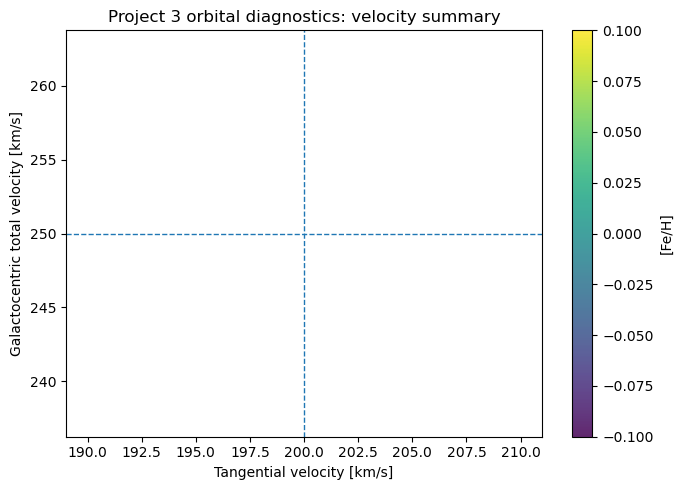

Wrote: ../figures/project3_orbital_diagnostics_velocity_summary.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    work["tangential_velocity_kms"],
    work["galcen_vtot_recomputed_kms"],
    c=work["feh"],
    s=45,
    alpha=0.85,
)

ax.axhline(250, linestyle="--", linewidth=1)
ax.axvline(200, linestyle="--", linewidth=1)

ax.set_xlabel("Tangential velocity [km/s]")
ax.set_ylabel("Galactocentric total velocity [km/s]")
ax.set_title("Project 3 orbital diagnostics: velocity summary")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("[Fe/H]")

fig.tight_layout()
fig_path = FIG_DIR / "project3_orbital_diagnostics_velocity_summary.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(f"Wrote: {fig_path}")


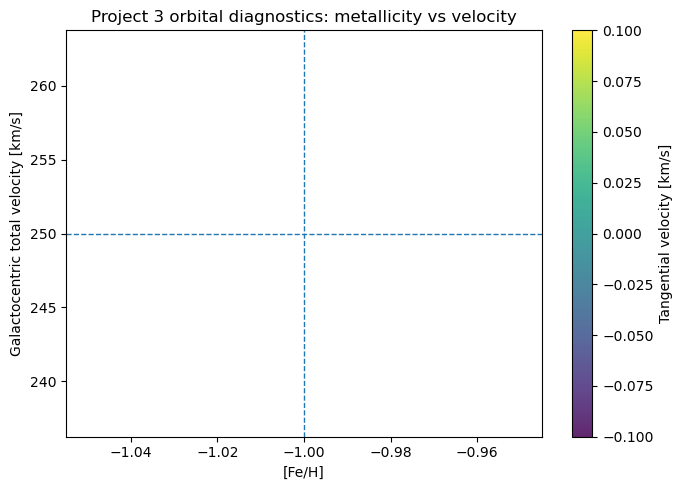

Wrote: ../figures/project3_orbital_diagnostics_feh_velocity.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    work["feh"],
    work["galcen_vtot_recomputed_kms"],
    c=work["tangential_velocity_kms"],
    s=45,
    alpha=0.85,
)

ax.axhline(250, linestyle="--", linewidth=1)
ax.axvline(-1.0, linestyle="--", linewidth=1)

ax.set_xlabel("[Fe/H]")
ax.set_ylabel("Galactocentric total velocity [km/s]")
ax.set_title("Project 3 orbital diagnostics: metallicity vs velocity")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Tangential velocity [km/s]")

fig.tight_layout()
fig_path = FIG_DIR / "project3_orbital_diagnostics_feh_velocity.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(f"Wrote: {fig_path}")


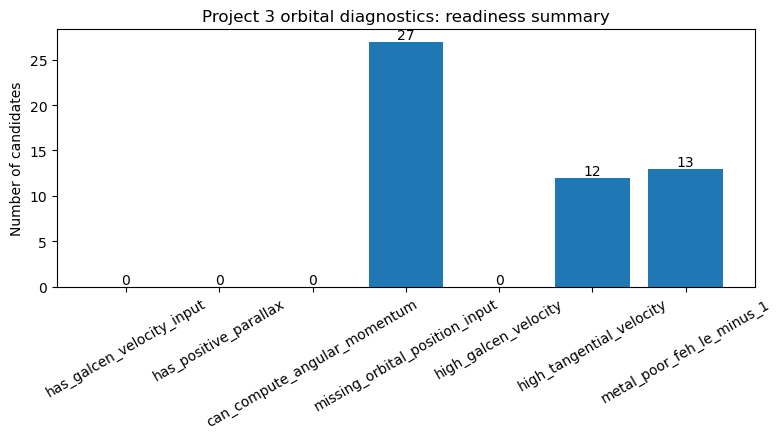

Wrote: ../figures/project3_orbital_diagnostics_readiness_summary.png


In [10]:
plot_summary = readiness_summary.copy()
plot_summary = plot_summary[plot_summary["category"] != "candidate_rows"]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(plot_summary["category"], plot_summary["count"])
ax.set_ylabel("Number of candidates")
ax.set_title("Project 3 orbital diagnostics: readiness summary")
ax.tick_params(axis="x", rotation=30)

for idx, row in enumerate(plot_summary.itertuples(index=False)):
    ax.text(idx, row.count, str(row.count), ha="center", va="bottom")

fig.tight_layout()
fig_path = FIG_DIR / "project3_orbital_diagnostics_readiness_summary.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(f"Wrote: {fig_path}")


In [11]:
print("Project 3 M3 compact summary")
print("============================")
print(f"Candidate rows: {len(work)}")
print(f"Rows with Galactocentric velocity input: {int(work['has_galcen_velocity_input'].sum())}")
print(f"Rows with positive parallax: {int(work['has_positive_parallax'].sum())}")
print(f"Rows able to compute angular momentum now: {int(work['can_compute_angular_momentum'].sum())}")
print(f"Rows missing orbital position input: {int(work['missing_orbital_position_input'].sum())}")
print()
print(f"Median [Fe/H]: {work['feh'].median():.3f}")
print(f"Median tangential velocity [km/s]: {work['tangential_velocity_kms'].median():.3f}")
print(f"Median Galactocentric vtot [km/s]: {work['galcen_vtot_recomputed_kms'].median():.3f}")
print(f"Max Galactocentric vtot [km/s]: {work['galcen_vtot_recomputed_kms'].max():.3f}")
print()
print(readiness_summary.to_string(index=False))


Project 3 M3 compact summary
Candidate rows: 27
Rows with Galactocentric velocity input: 0
Rows with positive parallax: 0
Rows able to compute angular momentum now: 0
Rows missing orbital position input: 27

Median [Fe/H]: -0.951
Median tangential velocity [km/s]: 197.414
Median Galactocentric vtot [km/s]: nan
Max Galactocentric vtot [km/s]: nan

                      category  count  fraction
                candidate_rows     27  1.000000
     has_galcen_velocity_input      0  0.000000
         has_positive_parallax      0  0.000000
  can_compute_angular_momentum      0  0.000000
missing_orbital_position_input     27  1.000000
          high_galcen_velocity      0  0.000000
      high_tangential_velocity     12  0.444444
     metal_poor_feh_le_minus_1     13  0.481481
